<a href="https://www.kaggle.com/code/shravankumarpandey/quadratic-equation-using-langgraph?scriptVersionId=335502068" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

class QuadraticState(TypedDict):
    a:float
    b:float
    c:float
    D:float
    equation:str
    result:str

def show_equation_node(state:QuadraticState)->QuadraticState:
    equation=f"{state['a']}x^2+{state['b']}x+{state["c"]}"
    return {"equation":equation}

def QuadraticNode(state:QuadraticState)->QuadraticState:
    a=state["a"]
    b=state["b"]
    c=state["c"]
    D=b**2-4*a*c
    return {"D":D}

def RealRootNode(state:QuadraticState)->QuadraticState:
    a=state["a"]
    b=state["b"]
    c=state["c"]

    root1=(-b+(b**2-4*a*c)**2)/2*a
    root2=(-b-(b**2-4*a*c)**2)/2*a
    result=f"The roots of the given equation {state["equation"]} are {root1} and {root2}"
    return {"result":result}

def RepeatedRootNode(state:QuadraticState)->QuadraticState:
    a=state["a"]
    b=state["b"]
    root=(-b)/2*a
    result=f"The roots of the given equation {state["equation"]} are {root} and {root}"
    return {"result":result}


def NoRealRootNode(state:QuadraticState)->QuadraticState:
    result=f"The given equation {state["equation"]} has no real roots"
    return {"result":result}

def check_condition(state:QuadraticState)->Literal["RealRootNode","RepeatedRootNode","NoRealRootNode"]:

    d=state["D"]
    if d>0:
        return "RealRootNode"
    elif d==0:
        return "RepeatedRootNode"
    else:
        return "NoRealRootNode"




graph=StateGraph(QuadraticState)
graph.add_node("show_equation_node",show_equation_node)
graph.add_node("QuadraticNode",QuadraticNode)
graph.add_node("RealRootNode",RealRootNode)
graph.add_node("RepeatedRootNode",RepeatedRootNode)
graph.add_node("NoRealRootNode",NoRealRootNode)

graph.add_edge(START,"show_equation_node")
graph.add_edge("show_equation_node","QuadraticNode")
graph.add_conditional_edges("QuadraticNode",check_condition)
graph.add_edge("RealRootNode",END)
graph.add_edge("RepeatedRootNode",END)
graph.add_edge("NoRealRootNode",END)


workflow=graph.compile()



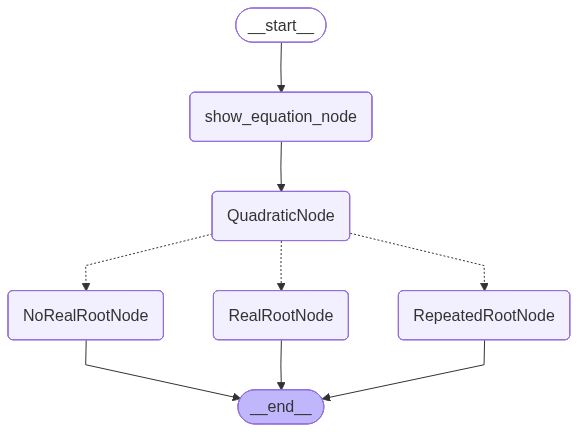

In [2]:
workflow

# No Real Root

In [3]:
initial_state={
    "a":5,
    "b":10,
    "c":12,
}
result=workflow.invoke(initial_state)
print(result)

{'a': 5, 'b': 10, 'c': 12, 'D': -140, 'equation': '5x^2+10x+12', 'result': 'The given equation 5x^2+10x+12 has no real roots'}


# Real Root

In [4]:
initial_state={
    "a":1,
    "b":3,
    "c":2,
}
result=workflow.invoke(initial_state)
print(result)

{'a': 1, 'b': 3, 'c': 2, 'D': 1, 'equation': '1x^2+3x+2', 'result': 'The roots of the given equation 1x^2+3x+2 are -1.0 and -2.0'}


# Repeated Root

In [5]:
initial_state={
    "a":1,
    "b":4,
    "c":4,
}
result=workflow.invoke(initial_state)
print(result)

{'a': 1, 'b': 4, 'c': 4, 'D': 0, 'equation': '1x^2+4x+4', 'result': 'The roots of the given equation 1x^2+4x+4 are -2.0 and -2.0'}
